# Apple (AAPL) - Modeling

## Objective
Build and evaluate regression models to predict next-day returns using time-series validation.

## Approach
- Use engineered features
- Apply TimeSeriesSplit
- Start with baseline (Linear Regression)
- Compare with LightGBM

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

In [7]:
stock = pd.read_csv('../data/processed/feature_data2.csv')
stock.drop(['Date'], axis = 1 , inplace = True)
stock = stock.sort_index()

X = stock.drop(columns=['Target'])
y = stock['Target']

# تنظيف
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

y = y.loc[X.index]

In [8]:
# stock.drop(['Date'], axis = 1 , inplace = True)

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

In [10]:
lr_mae = []
lr_rmse = []

for train_idx, test_idx in tscv.split(X):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    lr_mae.append(mae)
    lr_rmse.append(rmse)

In [11]:
print("Linear Regression Results")
print("MAE per fold:", lr_mae)
print("RMSE per fold:", lr_rmse)

print("Average MAE:", np.mean(lr_mae))
print("Average RMSE:", np.mean(lr_rmse))

Linear Regression Results
MAE per fold: [0.01957169212170964, 0.027328534186454995, 0.046022394738679084, 0.015275174577002875, 0.015520300481406712]
RMSE per fold: [np.float64(0.02696933760680287), np.float64(0.03909212581606301), np.float64(0.06524884419509759), np.float64(0.02057221726259646), np.float64(0.021563679523578926)]
Average MAE: 0.024743619221050662
Average RMSE: 0.03468924088082777


In [12]:
lgb_mae = []
lgb_rmse = []

for train_idx, test_idx in tscv.split(X):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = lgb.LGBMRegressor(random_state = 42)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    lgb_mae.append(mae)
    lgb_rmse.append(rmse)

C:\Users\Abubakr Awad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Abubakr Awad\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Abubakr Awad\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Abubakr Awad\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001713 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6885
[LightGBM] [Info] Number of data points in the train set: 1896, number of used features: 27
[LightGBM] [Info] Start training from score 0.001212
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001494 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6890
[LightGBM] [Info] Number of data points in the train set: 3788, number of used features: 28
[LightGBM] [Info] Start training from score 0.000701
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001631 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6890
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 28
[LightGBM] [Info] Start traini

In [14]:
print("\nLightGBM Results")
print("MAE per fold:", lgb_mae)
print("RMSE per fold:", lgb_rmse)

print("Average MAE:", np.mean(lgb_mae))
print("Average RMSE:", np.mean(lgb_rmse))


LightGBM Results
MAE per fold: [0.023413560838337684, 0.02862110210232009, 0.02189385938491675, 0.011778993448209298, 0.013957930666757145]
RMSE per fold: [np.float64(0.031537107584683075), np.float64(0.04127710602072304), np.float64(0.02923704231405057), np.float64(0.0162851480656444), np.float64(0.01976674792856834)]
Average MAE: 0.019933089288108195
Average RMSE: 0.027620630382733886


In [ ]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(10))

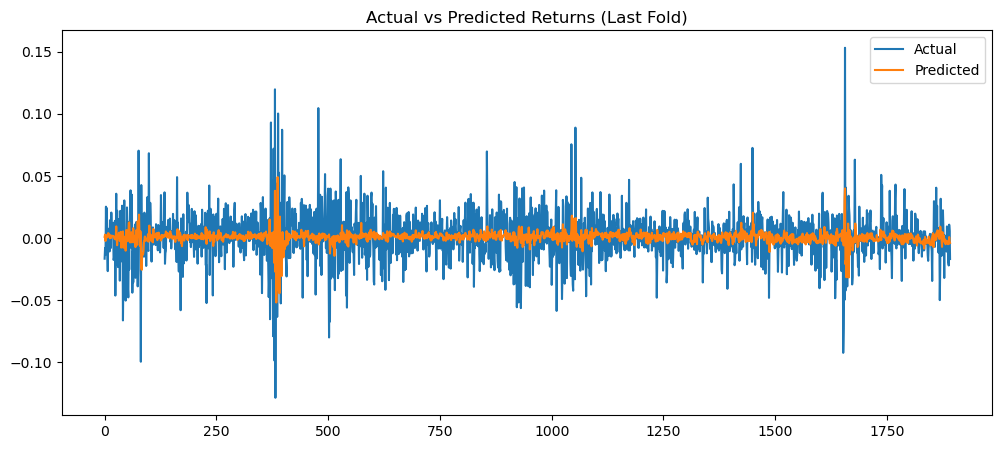

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')

plt.legend()
plt.title('Actual vs Predicted Returns (Last Fold)')
plt.show()

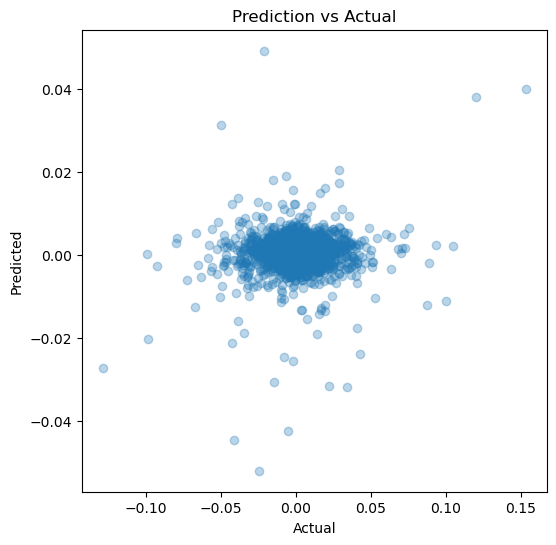

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediction vs Actual")
plt.show()

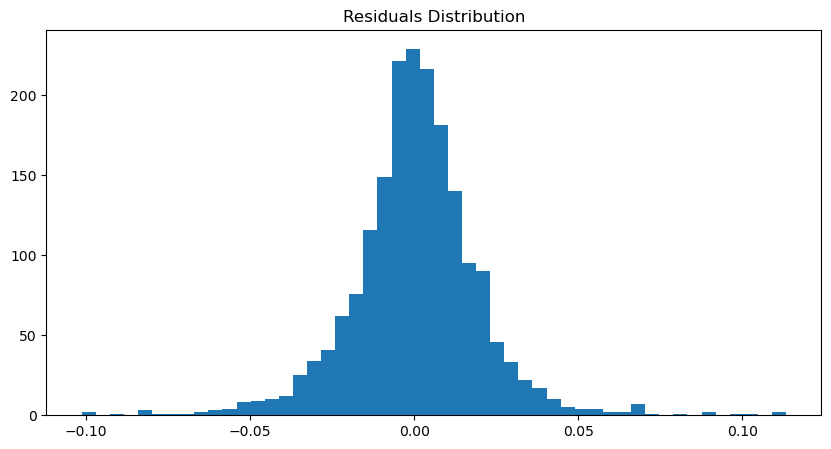

In [18]:
residuals = y_test.values - y_pred

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=50)
plt.title('Residuals Distribution')
plt.show()

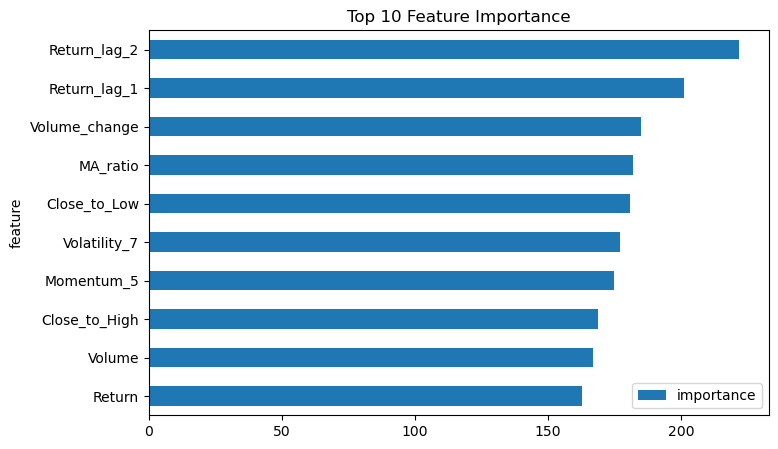

In [26]:
importance.head(10).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,5)
)

plt.title('Top 10 Feature Importance')
plt.gca().invert_yaxis()
plt.show()

## Modeling Insights

- LightGBM outperformed Linear Regression, indicating presence of non-linear relationships
- Performance improvement from feature engineering was modest but consistent
- Model performance varies across time splits, suggesting market instability
- Short-term returns remain difficult to predict accurately due to noise

## Conclusion

- The model captures weak but real signals
- Further improvements depend more on feature quality than model complexity